In [1]:
import pandas as pd
import matplotlib.pyplot as plt

RAW_PATH = '../data/raw/Amazon_Reviews.csv'
OUT_PATH = '../data/processed/reviews_clean.parquet'

## Explore df details

In [2]:
df = pd.read_csv(RAW_PATH,engine='python')
print(df.shape)
df.head(3)

(21214, 9)


,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"


## Get dataframe stuctures

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21214 entries, 0 to 21213
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Reviewer Name       21214 non-null  str  
 1   Profile Link        21163 non-null  str  
 2   Country             21054 non-null  str  
 3   Review Count        21055 non-null  str  
 4   Review Date         21055 non-null  str  
 5   Rating              21055 non-null  str  
 6   Review Title        21055 non-null  str  
 7   Review Text         21055 non-null  str  
 8   Date of Experience  20947 non-null  str  
dtypes: str(9)
memory usage: 13.7 MB


In [4]:
df.isna().sum()

Reviewer Name           0
Profile Link           51
Country               160
Review Count          159
Review Date           159
Rating                159
Review Title          159
Review Text           159
Date of Experience    267
dtype: int64

In [5]:
df = df.dropna(subset=['Review Text']).copy()
print(f"Amount {len(df):,} rows")

Amount 21,055 rows


## Tranform rating from STR to INT

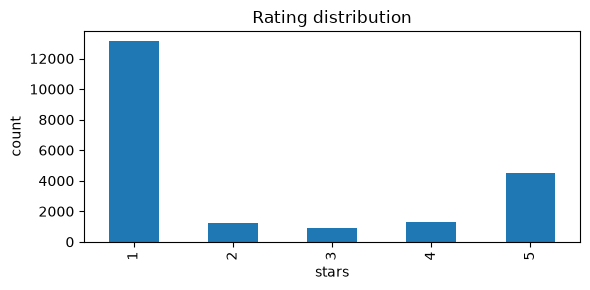

In [6]:
df['rating'] = df['Rating'].str.extract(r'(\d)').astype(int)

ax = df['rating'].value_counts().sort_index().plot(kind='bar',figsize=(6,3))
ax.set_title('Rating distribution')
ax.set_xlabel('stars'); ax.set_ylabel('count')
plt.tight_layout(); plt.show()

In [7]:
def make_document(title,text):
    title = title.strip() if isinstance(title,str) else ''
    text = text.strip()
    core = title.rstrip('...').rstrip('.').strip()
    if core and text.lower().startswith(core.lower()):
        return text # Title and text first sentence is the same
    return f"{title}. {text}".strip('. ').strip() if title else text

df['document'] = [make_document(t, x) for t,x in zip(df['Review Title'], df['Review Text'])]

print(df.iloc[1]['document'][:150])

Had multiple orders one turned up and…. Had multiple orders one turned up and driver had to phone as no door number on packaging, then waited all day 


In [8]:
before = len(df)
df =df[df['document'].str.len() >= 20]
print(f"Drop shorty text: {before - len(df)} rows")

before = len(df)
df = df.drop_duplicates(subset='document')
print(f"drop duplicate: {before - len(df)} rows")

Drop shorty text: 33 rows
drop duplicate: 35 rows


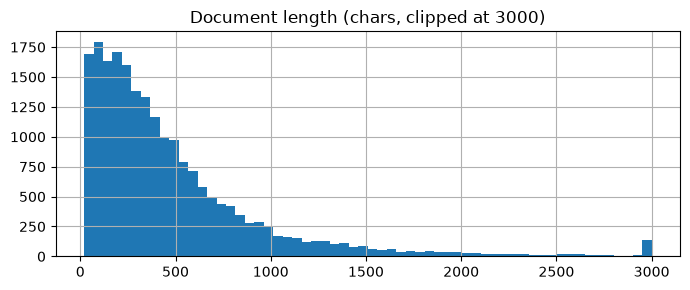

count    20987.0
mean       488.7
std        520.9
min         20.0
25%        172.0
50%        343.0
75%        613.0
max      10037.0
Name: document, dtype: float64

In [9]:
lens = df['document'].str.len()
ax = lens.clip(upper=3000).hist(bins=60,figsize=(7,3))
ax.set_title('Document length (chars, clipped at 3000)')
plt.tight_layout(); plt.show()
lens.describe().round(1)

In [10]:
df['review_date'] = pd.to_datetime(df['Review Date'],errors='coerce',utc=True)
df['country'] = df['Country'].fillna('unknown')

clean = df[['document','rating','review_date','country']].reset_index(drop=True)
clean['review_id'] = clean.index.astype(str)

print(clean.shape)
clean.head(3)

(20987, 5)


,document,rating,review_date,country,review_id
0,A Store That Doesn't Want to Sell Anything. I ...,1,2024-09-16 13:44:26+00:00,US,0
1,Had multiple orders one turned up and…. Had mu...,1,2024-09-16 18:26:46+00:00,GB,1
2,I informed these reprobates that I WOULD NOT B...,1,2024-09-16 21:47:39+00:00,GB,2


In [11]:
from pathlib import Path
Path('../data/processed').mkdir(parents=True, exist_ok=True)
clean.to_parquet(OUT_PATH,index=False)
print(f"saved -> {OUT_PATH}")

saved -> ../data/processed/reviews_clean.parquet
